In [1]:
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml('mnist_784')

In [3]:
x, y = mnist['data'], mnist['target']

In [4]:
import matplotlib
import matplotlib.pyplot as plt

In [5]:
some_digit = x.iloc[36000]
some_digit_image = some_digit.values.reshape(28, 28)

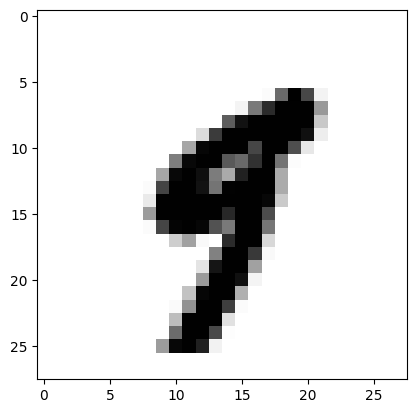

In [6]:
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation="nearest")

In [7]:
x_train, x_test, y_train, y_test = x[:60000], x[60000:] ,y[:60000], y[60000:]

In [8]:
import numpy as np
shuffle_index = np.random.permutation(60000)
X_train, y_train = x_train.iloc[shuffle_index], y_train.iloc[shuffle_index]

In [9]:
y_train_2 = (y_train == '2')
y_test_2 = (y_test == '2')

In [10]:
y_test_2

,class
60000,False
60001,True
60002,False
60003,False
60004,False
...,...
69995,True
69996,False
69997,False
69998,False


In [11]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_2)

SGDClassifier(random_state=42)

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3)

# Calculate metrics
conf_matrix = confusion_matrix(y_train_2, y_train_pred)
precision = precision_score(y_train_2, y_train_pred)
recall = recall_score(y_train_2, y_train_pred)
f1 = f1_score(y_train_2, y_train_pred)
accuracy = accuracy_score(y_train_2, y_train_pred)

print("Confusion Matrix:")
print(conf_matrix)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Confusion Matrix:
[[53578   464]
 [ 1150  4808]]

Precision: 0.9120
Recall: 0.8070
F1 Score: 0.8563
Accuracy: 0.9731


In [13]:
from sklearn.model_selection import cross_val_score

# By default, cross_val_score uses K-fold cross-validation and returns accuracy scores.
# We'll use 3 folds (cv=3) consistent with previous steps.
cross_val_accuracy_scores = cross_val_score(sgd_clf, X_train, y_train_2, cv=3, scoring="accuracy")

print("Cross-validation accuracy scores:")
print(cross_val_accuracy_scores)
print(f"Mean accuracy: {cross_val_accuracy_scores.mean():.4f}")
print(f"Standard deviation of accuracy: {cross_val_accuracy_scores.std():.4f}")

Cross-validation accuracy scores:
[0.9735 0.9719 0.9739]
Mean accuracy: 0.9731
Standard deviation of accuracy: 0.0009


To create a classifier that always predicts 'not 2', you can use Scikit-Learn's `DummyClassifier`. This type of classifier serves as a simple baseline, predicting according to a specified strategy. In your case, we want it to always predict the negative class (not '2').

In [14]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="constant", constant=False)
dummy_clf.fit(X_train, y_train_2)

dummy_y_pred = dummy_clf.predict(X_train)

from sklearn.metrics import accuracy_score

print(f"Dummy Classifier Accuracy: {accuracy_score(y_train_2, dummy_y_pred):.4f}")

Dummy Classifier Accuracy: 0.9007
